In [2]:
import os
import sys
import anndata as ad
import scipy
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import scipy.io as sio
import scanpy.external as sce
import matplotlib.pyplot as plt
import re
import gseapy as gp
import anndata as ad
import statistics
import tempfile
import sklearn
import cosg
import leidenalg
import celltypist
import muon as mu
from tqdm import tqdm
sc._settings.ScanpyConfig.n_jobs= 24
sc.settings.verbosity = 1
# Adjust Scanpy figure defaults
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=400,
    facecolor = 'white', figsize=(8,8), format='png')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [3]:
def check_dict_duplicates(dict):
    seen = set()
    dup = any(item in seen or seen.add(item) for lst in dict.values() for item in lst)
    if dup==False:
        return '无重复'
    else:
        return '有重复'

In [4]:
os.environ["R_HOME"] = "/home/liyanguo/anaconda3/envs/R/lib/R/"
import rpy2.rinterface_lib.callbacks
import anndata2ri
import logging

from rpy2.robjects import pandas2ri
from rpy2.robjects import r

sc.settings.verbosity = 0
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

cffi mode is CFFI_MODE.ANY
R home found: /home/liyanguo/anaconda3/envs/R/lib/R/
R library path: WARNING: ignoring environment value of R_HOME

LD_LIBRARY_PATH: WARNING: ignoring environment value of R_HOME

Default options to initialize R: rpy2, --quiet, --no-save
R is already initialized. No need to initialize.


In [5]:
%%R
suppressPackageStartupMessages({
    library(Seurat)
    library(clusterProfiler)
    library(ggplot2)
    library(dplyr)
    library(anndata)
    library(SingleCellExperiment)
    library(reticulate)
})


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

In [6]:
obj_path = '/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Level2_Refine_R1/'

In [7]:
leiden_groups=['L2_leiden_TOTALVI_0.5', 'L2_leiden_TOTALVI_1', 'L2_leiden_TOTALVI_1.5','L2_leiden_TOTALVI_2','L2_leiden_TOTALVI_3',]

In [8]:
def get_annotation_data(celltype):
    adata = sc.read_h5ad(f"{obj_path}/{celltype}/{celltype}_count_scRNA.h5ad",backed='r')
    adt = sc.read_h5ad(f"{obj_path}/{celltype}/{celltype}_preprocess_scADT.h5ad")
    adata.obsm = adt.obsm
    
    # read Level1, tcr, bcr infor
    indices = pd.read_csv(f'{obj_path}/{celltype}/R1_indices_{celltype}.csv',index_col=0)
    # join leiden groups
    leiden_data = adt.obs.loc[:,leiden_groups]
    adata.obs = adata.obs.join(indices, how='left')
    adata.obs = adata.obs.join(leiden_data, how='left')
    adata.strings_to_categoricals()
    return adata,adt,leiden_data

In [9]:
def get_norm_annotation_data(celltype):
    adata = sc.read_h5ad(f"{obj_path}/{celltype}/{celltype}_count_scRNA.h5ad")
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adt = sc.read_h5ad(f"{obj_path}/{celltype}/{celltype}_preprocess_scADT.h5ad")
    adata.obsm = adt.obsm
    
    # read Level1, tcr, bcr infor
    indices = pd.read_csv(f'{obj_path}/{celltype}/R1_indices_{celltype}.csv',index_col=0)
    # join leiden groups
    leiden_data = adt.obs.loc[:,leiden_groups]
    adata.obs = adata.obs.join(indices, how='left')
    adata.obs = adata.obs.join(leiden_data, how='left')
    return adata,adt,leiden_data

# 1. Basophil Cell Refine

In [10]:
celltype="Basophil"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [11]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [ ]:
leiden_data.to_csv(f'{R_data_path}/Level2_TOTALVI_ForClustree.csv')
os.system(f'/home/liyanguo/anaconda3/envs/R/bin/Rscript clustree_L2.R {R_data_path} &')

In [12]:
groupby = "L2_leiden_TOTALVI_1"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L2_metadata.png')

In [ ]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='HDC',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD79A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adt, color='CD3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],layer='denoised_protein',show=False)
#TNFAIP3/CXCR4/DDIT4/FOSL2/IRS2/BTG1/ZFP36/PNRC1/CDKN1B/PLIN2/BHLHE40/PLAUR/ETS1/DUSP1
#SELL/TXNIP/IFITM2/B2M/HLA-C

sc.pl.violin(adata,'CXCR4',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'CSF3R',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'IL16',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adt,'CD14',groupby=groupby,show=False, ax=axs[1,3],size=0.5,layer='denoised_protein')#
plt.show()

In [14]:
adata.obs[groupby].value_counts()

L2_leiden_TOTALVI_1
9     18353
6     16050
3     14875
0      9974
2      3632
8      3148
7      2865
5      2449
4      1867
10     1821
1      1440
Name: count, dtype: int64

In [13]:
# 特征CD25偏高 CCR3 CSF2RB
cell_dict = {'Doublet':['0',#low quality of CD4
                        '2',#T
                        '5',#Platelet T
                        '10',#Platelet NK
                        '1',#B
                        '7',#Neu
                        '8',# mix in adt
                       ],
             'Basophil':['3','4','6','9'
                        ],
            }

In [15]:
check_dict_duplicates(cell_dict)

'无重复'

In [16]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2_Refine'] = i

In [17]:
(adata.obs['Celltype_L1_L2_Refine'].isna()).value_counts()

Celltype_L1_L2_Refine
False    76474
Name: count, dtype: int64

In [18]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Basophil    51145
Doublet     25329
Name: count, dtype: int64

In [19]:
adata.obs.loc[adata.obs['receptor_type']=='TCR','Celltype_L1_L2_Refine']="Doublet"
adata.obs.loc[adata.obs['receptor_type_BCR']=='BCR','Celltype_L1_L2_Refine']="Doublet"

In [20]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Basophil    51145
Doublet     25329
Name: count, dtype: int64

In [21]:
adata = adata[adata.obs['Celltype_L1_L2_Refine'] != "Doublet",:]

In [22]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Basophil    51145
Name: count, dtype: int64

In [23]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R1_refine_indices_{celltype}.csv")

# 2. HSPC Cell Refine

In [278]:
celltype="HSPC"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [279]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [ ]:
leiden_data.to_csv(f'{R_data_path}/Level2_TOTALVI_ForClustree.csv')
os.system(f'/home/liyanguo/anaconda3/envs/R/bin/Rscript clustree_L2.R {R_data_path} &')

In [280]:
groupby = "L2_leiden_TOTALVI_1"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L2_metadata.png')

In [ ]:
genes_to_check ={
'HSC': ['HLF','NOG','PROM1','AVP','KLF2','CRHBP','HOPX','IDS','BST2','SPINK2'],
'MPP': ['C1QTNF4','SMIM24','SELL',],
'GMP': ['MPO','ELANE','AZU1','PRTN3','CALR','CFD','CTSG','MGST1','PRSS57'],
'NeuP': ['LYZ','LGALS1','CTSG','ANXA2'],
'MDP': ['SPIB','CD68','JCHAIN','IRF7','IRF8','PLD4','LILRA4','GZMB','CCDC50','SCT','UGCG'],
'EBMP': ['CLC','MS4A3','TPSAB1','MS4A2','LMO4','HDC'],
'CLP': ['DNTT','JCHAIN','IL7R','ADA','TRBC2','SATB1'],
'preB1': ['HMGB2','STMN1','CCND3','HMGN2',],
'preB2_3': ['CD9','CD79B','VPREB3','VPREB1','DNTT','ARPP21','AKAP12','CD79A','MZB1','MDM4'],
'preB3': ['GATA1','GATA2','TESPA1','CTNNBL1'],
'NK/Tp': ['CD96','IL32','KLRB1','TRAC','CD3E','TRBC1','CD3D','CCL5','CD7','NKG7'],
'MEP': ['APOC1','HBD','KLF1','BLVRB','TMEM14C','ITGA2B','MYC'],
'MKp1': ['GATA2','FCER1A','PBX1','CYTL1','SLC40A1'],
'MKp2': ['PPBP','PF4','NRGN','PLEK','RGS18','PDLIM1'],
'Eryp': ['HBB','HBA2','HBA1','AHSP','CA1','FAM178B',],
}
#Deciphering transcriptome alterations in bone marrow hematopoiesis at single-cell resolution in immune thrombocytopenia. Signal Transduct Target Ther 2022 Oct 7;7(1):347. PMID: 36202780

In [ ]:
sc.pl.dotplot(adata, genes_to_check,
             groupby=groupby,
             dendrogram=False,
             swap_axes=False,
             standard_scale='var',
              save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
tfs_to_check ={
'HSC|MPP': ['AVP','KLF2','CRHBP','HOPX','BST2','SPINK2','MECOM','HOXA7','HOXA3','HESX1'],
'GMP|NeuP': ['CEBPA','ASCL2','CEBPD','CEBPE'],
'MDP': ['IRF7','SPIB','IRF4'],
'EBMP': ['POU2F2','GATA2','IKZF2','MEIS2','MITF'],
'CLP': ['MAFK','MEF2A',],
'preB1': ['E2F7','E2F8','E2F2'],
'preB2|3': ['BACH2','TCF3','FOXO1','EBF1','PAX5'],
'NK/Tp': ['RORA','EOMES','TBX21','BCL11B'],
'MEP|MKp1|MKp2|Eryp': ['GFI1B','GATA1','NFIB','HES5','PPARA'],
}
#Deciphering transcriptome alterations in bone marrow hematopoiesis at single-cell resolution in immune thrombocytopenia. Signal Transduct Target Ther 2022 Oct 7;7(1):347. PMID: 36202780

In [ ]:
sc.pl.dotplot(adata, tfs_to_check,
             groupby=groupby,
             dendrogram=False,
             swap_axes=False,
             standard_scale='var',
             cmap='Spectral_r')

In [ ]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD79A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adt, color='CD3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],layer='denoised_protein',show=False)
#TNFAIP3/CXCR4/DDIT4/FOSL2/IRS2/BTG1/ZFP36/PNRC1/CDKN1B/PLIN2/BHLHE40/PLAUR/ETS1/DUSP1
#SELL/TXNIP/IFITM2/B2M/HLA-C

sc.pl.violin(adata,'CXCR4',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'CSF3R',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'IL16',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adt,'CD14',groupby=groupby,show=False, ax=axs[1,3],size=0.5,layer='denoised_protein')#
plt.show()

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='IL7R',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='KIT',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='MPL',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'SPI1',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'GATA2',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'CD38',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adata,'CD34',groupby=groupby,show=False, ax=axs[1,3],size=0.5)
plt.show()
# PU.1/  CD71/ HBD MYB IL1B ITGA2B-low ALDH1A1 ST8SIA6 GMPR TPO MPL=CD110+ FLT3low GATA1 血红素代谢 CD45RA-

In [ ]:
sc.pl.umap(adata, color='CD34',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [282]:
adata.obs[groupby].value_counts()

L2_leiden_TOTALVI_1
0     6210
1     5981
4     5612
2     2123
9     1908
5     1697
10    1418
3      956
7      490
8      420
11     407
13     271
6      227
12     179
Name: count, dtype: int64

In [283]:
cell_dict = {
            'Mast':['9'],#KIT等
    
            'Doublet':['6',#成熟Mono才表达CD14
                       '3','2',#同时表达FCGR3A\FCGR3B, CSF3R CD16+
                       '7',#Mast Neu CD16+
                       '10',#CD3+，CLP从骨髓到胸腺，是不表达CD3的；CD3+
                       '12',#B transitional B IGD+ IGM+
                       '13',#adt
                       ],
            'HSPC':['0','1',#MPL
                    '4',
                    '8',
                    '11',
                    '5',#KIT+ IL7R- NFIL3+ AHR+ 
                    ],
            }
#CD7- 	CD34+ CD133+ SPI1 MYB MPL=CD110+ CSF3R=G-CSFR+  CD45RA-
#'Circulating MEPs'
#CD34+ CD38+ CD123- FLT3=CD135+ CD45RA-   CD38-low  AVP 
#'Circulating MkPs'#megakaryocyte  progenitor cells  PLEK

#CD7low CD34-  KIT+ CD133- FLT3=CD135+ PLD4  SPIB SPI1+(出骨髓的) CD45RA- IL7R- LMO4 MHCII+
#'Circulating MDPs'#common DC cell progenitors
#CCR7 RUNX2  JCHAIN   IGHM IGHD SOX4 GATA1- CD38- RORC

#CD7- 	CD34+  CD133+ KIT- FLT3=CD135+ PU.1/SPI1+(出骨髓的) MME CD45RA- IL7R-  ADA 
#'Circulating CLPs'
#CCR7  RUNX2  JCHAIN DNTT/tdt  IGHM IGHD SOX4 GATA1- CD38- LMO4

#Lin- CD7+ KIT+ CD96+ IL7R+ SELPLG+(CLP前往胸腺的因子) CD45RA+  SOX4-  FLT3=CD135-  CXCR4low SELL
#'Circulating NK/TPs'
#TCF7 IL32 ETS1（表明已经过了CLP阶段）  IL2RA=CD25+
#ILC2表达GATA3,但是需要KIT-/CRTH2+,所以不是
#ILC3需要RORC和AHR+，不是

# ATXN1（SCA1）
#T-restricted progenitors, circulating T progenitors, T-committed precursors PMID: 21251013, PMID: 17222572
#GMP 需要MPO
#https://www.nature.com/articles/s41467-022-29675-w    CD34+EPCR(PROCR)+(CD38/CD45RA)−   CD34+CD38−CD45RA− HSC    CD90+CD49f(ITGA6)+ HSC and CD90−CD49f− MPPs      CD90+CD49f+ and CD90−CD49f+ HSC
#https://www.cell.com/cell/fulltext/S0092-8674(24)00408-2#author-highlights-abstract MEP  AVP
#https://www.bdbiosciences.com/content/dam/bdb/marketing-documents/BD_Multiparametric_Immuno_Stem_Cells_AppNote.pdf
#https://link.springer.com/article/10.1007/s00018-018-2865-1#Sec3 NK ILC问题
# From stem cell to T cell: one route or many? 
# 血液中 HSC 的频率随昼夜节律振荡而波动，在光明开始后 5 小时达到峰值，在天黑后至少 5 小时达到峰值。我们在早上取样的（PMID: 18256599）
#  Exacting experiments to uncover the mechanisms of lymphoid progenitor homing from the BM to the thymus have been hampered by difficulties in identifying the relevant progenitor population

In [284]:
check_dict_duplicates(cell_dict)

'无重复'

In [285]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2_Refine'] = i

In [286]:
(adata.obs['Celltype_L1_L2_Refine'].isna()).value_counts()

Celltype_L1_L2_Refine
False    27899
Name: count, dtype: int64

In [287]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
HSPC       20327
Doublet     5664
Mast        1908
Name: count, dtype: int64

In [288]:
adata.obs.loc[adata.obs['receptor_type']=='TCR','Celltype_L1_L2_Refine']="Doublet"
adata.obs.loc[adata.obs['receptor_type_BCR']=='BCR','Celltype_L1_L2_Refine']="Doublet"

In [289]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
HSPC       18927
Doublet     7172
Mast        1800
Name: count, dtype: int64

In [290]:
adata = adata[adata.obs['Celltype_L1_L2_Refine'] != "Doublet",:]

In [291]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
HSPC    18927
Mast     1800
Name: count, dtype: int64

In [292]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R1_refine_indices_{celltype}.csv")

# 3. B Cell Refine

In [10]:
celltype="B"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [11]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [ ]:
leiden_data.to_csv(f'{R_data_path}/Level2_TOTALVI_ForClustree.csv')
os.system(f'/home/liyanguo/anaconda3/envs/R/bin/Rscript clustree_L2.R {R_data_path} &')

In [12]:
groupby = "L2_leiden_TOTALVI_1.5"

In [ ]:
#由于 新生儿脐带血中主要由过渡B组成，观察一下

In [17]:
adata.obs['batch'] = adt.obs['Batch']

In [20]:
adata_new = adata[adata.obs['DonorID']=='D0144',:]

In [21]:
adata_new

View of AnnData object with n_obs × n_vars = 1505 × 38606
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Reference_Atlas_L1L2_mv', 'Reference_Atlas_L1L2_pl', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'percent.mt', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'mapping.score', 'scDblFinder.class', 'Celltype_L1_L2', 'receptor_type', 'receptor_type_BCR', 'L1_leiden_TOTALVI_3', 'L2_leiden_TOTALVI_0.5', 'L2_leiden_TOTALVI_1', 'L2_leiden_TOTALVI_1.5', 'L2_leiden_TOTALVI_2', 'L2_leiden_TOTALVI_3', 'batch'
    uns: 'log1p'
    obsm: 'X_TOTALVI', 'X_umap'

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata_new, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata_new, color='CD9',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata_new, color='CD38',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata_new, color='CD27',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata_new,'IGHM',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata_new,'IGHD',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata_new,'IGHG1',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adata_new,'ITGAX',groupby=groupby,show=False, ax=axs[1,3],size=0)
plt.show()

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L2_metadata.png')

In [24]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD9',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='PAX5',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CD27',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'IGHM',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'IGHD',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'IGHG1',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adata,'ITGAX',groupby=groupby,show=False, ax=axs[1,3],size=0)
plt.show()

In [ ]:
#Transitional MME, CD9, CD38, PAX5, and FCER2
sc.pl.dotplot(adata, ['MME','CD38','CD9','FCER2','CR2','CD5','MS4A1',
    'TNFRSF13C','CD24','C1QC','C1QA','CD93',
                      'FCRL4','CD180','IL2RA',
                      'BACH2','PAX5',
                      'CD93','IL7R','IL4R','FAS','NOTCH2',
                      'FOXO1','IKZF1','IKZF3','TCF3',
                      'EBF1','SSBP2','BACH2','PRKCE','RUNX1','BCL2','POU2F2','BCL6',
                      'CD1C','CD1D','CD5','ZBTB16','CR2','CR1',
                     'CTLA4','TFRC'],
              standard_scale='obs',groupby=groupby)

In [ ]:
#atypical B
sc.pl.dotplot(adata, ['SIGLEC6','ITGAX','PTPRS','ZBTB32','SOX5','IGHG1',
                      'SYT1','MX1','SHISA8','LGMN','TOX2','IGHG4','PALS2','CD86','GPR137B','SEMA7A','FCRL5',
                     'LILRB2','TOX','ENC1','TNFRSF1B',
                     'SOX5','CRIP1','PPP1R14A','FCRL3','FGR','CD1C',],
              standard_scale='var',groupby=groupby)

In [ ]:
#Type 2 polarized memory B cell: IL4R, FCER2, COCH, IGHG1, IGHG4, and IGHE. IGHE
# early memory: CD27, AIM2 and class-switched isotype IgH (IGHA1, IGHA2 and IGHG1, IGHG2, IGHG3, and IGHG4). ‘Intermediate’
# Activated memory cell
sc.pl.dotplot(adata, ['COCH','IL4R','FCER2','IL13RA1','CD24','TCL1A',
                      'IGHA1','IGHA2','IGHG1','IGHG2','IGHG3','IGHG4',
                      'IGHE','RNGTT','PDE4D','SELL','EAF2','FCGR2B','CXCR3','CCR7',
                      'ITGAX','CD24',
                     'AIM2','CD27','ENTPD1','LAIR1','CD72',
'ITGB1','S100A4','S100A10','CRIP1','CRIP2',
                     'NT5E','AREG','CDKN1A','NFKB1','NR4A2','MS4A1','FAS','JUN','FOS','MCL1','MYC','CTLA4','TNFRSF8','IL7',],
              standard_scale='var',groupby=groupby)

In [ ]:
#Type 2 polarized memory B cell: IL4R, FCER2, COCH, IGHG1, IGHG4, and IGHE. IGHE
# early memory: CD27, AIM2 and class-switched isotype IgH (IGHA1, IGHA2 and IGHG1, IGHG2, IGHG3, and IGHG4). ‘Intermediate’
# Activated memory cell
sc.pl.dotplot(adata, ['BTBD9',],
              standard_scale='var',groupby=groupby)

In [31]:
adata.obs[groupby].value_counts()

L2_leiden_TOTALVI_1.5
8     201289
18    182812
20    167448
2     151305
24    144703
16    138560
12    120053
14    112523
1     110139
10     86032
13     85034
5      81188
21     79629
9      75868
3      75041
4      71710
17     67825
15     57356
0      51822
11     50201
25     49127
22     41455
6      40860
7      38728
23     33591
19     33302
27     27181
26     20005
Name: count, dtype: int64

In [73]:
#CD23=FCER2 CR2=CD21

cell_dict = {'Plasma':['0',],#CD38，含有plamsablast
             'Doublet':['17',#Myeloid
                        '24','25','27',#Neu
                        '26',
                       ],#
             ###IgD low,CD27 low/neg, IgM+,HLA
             #Atypical memory=Age-associated B cell; 有的被简称为ABC细胞，如ABC_FCRL4
             #Gene: T-bet=TBX21;FCRL5,CXCR3,CD11c=ITGAX;FGR
             #adt Manni, M. et al. Regulation of age-associated B cells by IRF5 in systemic autoimmunity. Nat. Immunol. https://doi.org/10.1038/s41590-018-0056-8 (2018),看introduction,https://www.nature.com/articles/s41467-023-38810-0
             'Atypical memory B':['13',
                                '23'],#CD27lo IgD- IgM- IGHG

             #Naïve B,TCL1A, IL4R,FCER2,. CD19+, CD20+, CD27-, IgD+, IgM+,
             'Naïve B':['5','7','8','10','11','12',
                       '14','18','20','21','22',
                       '16',#TCL1A
                       ],

             'Memory B':['1','2','3','6',
                                '4',
                         '9','15',
                                  '19'#'Type 2 polarized memory B cell':[],#COCH, Type 2 polarized memory B cell, https://www.science.org/doi/10.1126/scitranslmed.adi0944
                               ],
            }

#https://www.cellsignal.cn/pathways/immune-cell-markers-human
#https://www.abcam.cn/primary-antibodies/b-cells-basic-immunophenotyping
#https://www.bdbiosciences.com/zh-cn/learn/research/immunology/b-cells#B-Cell-Immunophenotyping
#https://ashpublications.org/blood/article/114/25/5173/26511/An-in-vitro-model-of-differentiation-of-memory-B
#浆细胞、浆母细胞https://www.sohu.com/a/234622412_610701;
#https://zhuanlan.zhihu.com/p/56657003
#https://www.biocompare.com/Editorial-Articles/570578-A-Guide-to-B-Cell-Markers/
# https://www.cell.com/trends/immunology/fulltext/S1471-4906(22)00003-5#secst0040
# https://www.nature.com/articles/s41577-024-00991-0

# IgD的出现，意味着B细胞从原先耐受抗原的细胞，开始逐渐转变为可对抗原产生反应的B细胞了，
# 所以从T1、T2、T3开始IgD逐渐增高，到Naive达到高峰。当Naive刚变成Memory B时，IgD仍保留着，所以此时叫Unswitched（未转换），
# 只有Memory B的表面Ig从IgD转变为IgG、IgA或IgE时，才叫Switched Memory B
# ，就可以进一步向Plasmablast（浆母细胞）转换，开始大量分泌抗体。

In [74]:
check_dict_duplicates(cell_dict)

'无重复'

In [75]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2_Refine'] = i

In [76]:
(adata.obs['Celltype_L1_L2_Refine'].isna()).value_counts()

Celltype_L1_L2_Refine
False    2394787
Name: count, dtype: int64

In [77]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Naïve B              1299918
Memory B              615581
Doublet               308841
Atypical memory B     118625
Plasma                 51822
Name: count, dtype: int64

In [78]:
adata.obs.loc[adata.obs['receptor_type']=='TCR','Celltype_L1_L2_Refine']="Doublet"

In [79]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Naïve B              1232786
Memory B              582243
Doublet               418775
Atypical memory B     112350
Plasma                 48633
Name: count, dtype: int64

In [80]:
adata = adata[adata.obs['Celltype_L1_L2_Refine'] != "Doublet",:]

In [81]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Naïve B              1232786
Memory B              582243
Atypical memory B     112350
Plasma                 48633
Name: count, dtype: int64

In [82]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R1_refine_indices_{celltype}.csv")

# 4. CD4+ T Cell Refine

In [9]:
celltype="CD4T"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [10]:
adata,adt,leiden_data = get_annotation_data(celltype)

... storing 'Celltype_L1_L2' as categorical
... storing 'receptor_type' as categorical
... storing 'receptor_type_BCR' as categorical


In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [ ]:
leiden_data.to_csv(f'{R_data_path}/Level2_TOTALVI_ForClustree.csv')
os.system(f'/home/liyanguo/anaconda3/envs/R/bin/Rscript clustree_L2.R {R_data_path} &')

In [11]:
groupby = "L2_leiden_TOTALVI_1"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [120]:
cell_index = celltypist.samples.downsample_adata(adata,mode = 'each', n_cells = 5000,
                                                 by = groupby,
                                                 return_index = True,random_state=0)

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata[cell_index], keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata[cell_index], keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata[cell_index], keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata[cell_index], keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata[cell_index], keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata[cell_index], keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata[cell_index], keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L2_metadata.png')

In [ ]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CCR4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CSF3R',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)
sc.pl.umap(adata, color='CTLA4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,0],show=False)
sc.pl.umap(adata, color='SPON2',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,1],show=False)
sc.pl.umap(adata, color='FOXP3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,2],show=False)
sc.pl.umap(adata, color='CCR6',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,3],show=False)
plt.show()

In [ ]:
adata.obs['cluster_dummy'] = adata.obs[groupby] == adata.obs[groupby].cat.categories[16]
sc.pl.umap(adata, color='cluster_dummy',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [14]:
adata.obs[groupby].value_counts()

L2_leiden_TOTALVI_1
8     796759
4     745583
14    739730
17    713506
12    693564
9     687783
3     621630
16    411923
11    407118
13    383532
7     323367
5     304863
0     293079
1     266412
10    160098
2     146230
15     80602
6      53612
Name: count, dtype: int64

In [ ]:
sc.pl.dotplot(adata[cell_index], ['CCR4','CCR6','CXCR5','KLRB1','GZMK','CCL5','GZMB','BTBD9','CXCR3','GATA3','CCR10',
                      'LIMS1','RORC','CD27','CCR1','CCR2','PRDM1','CD27','CD28','CXCR5','KLRB1',
                      'TCF7','ICOS','CD27','CXCR3','PDCD1','TBX21','IL6R','TIGIT','GPR183',
                      'CCL5','CTLA4','CD40LG'],
              standard_scale='var',groupby=groupby)

In [15]:
#Naïve CD4+ T 需要CD45RA+ CCR7=CD197hi CD62Lhi
# effector memory T cells(TEM, CD45RA-/CCR7-)
# TEMRA cells, which are T cells that re-express CD45RA(CD45RA+/CCR7-)

# Treg:FOXP3+ CD25+
# Naive:CD45RA+ CCR7+
# CD4-help-memory(Th1-22,Tfh): CD45RA-
# CD4-CTL(Temra):GZMB
# Tcm：CD27hi CD28hi CD45RA- CCR7+

cell_dict = {'Doublet':['6',],#B混合
             #CD45RA- FOXP3 CD25
             'Treg':['0'],#CD279
             
             #CD45RA+ CCR7=CD197hi CD62Lhi ITGB1-
             'Naïve CD4+ T':['2','5','7','8','12',],#CD45RA+

             #CD45RA- CCR7+/-: TEM ITGB1+ GATA3
             'Helper memory CD4+ T':['1',
                                     '3',
                                     '4',
                                     '10',
                                     '11',
                                     '14',
                                     '15',
                                     '16',
                                     '17',
                                       ],
             
             #CD45RA- CCR7- CD27- CD28- GATA3
             'Cytotoxic CD4+ T':['9',#CD4+ CTL CD45RA- GNLY CCL5 GZMH PRF1 GZMB CST7 ITGAM ITGB1+ CD27-
                       ],

             #CD45RA lo
             'Low quality':['13'],#Gene: CD7-CD3- CD4 T BTBD9 SMYD3 ZBTB20 ARL15 RAD51B CAMKMT; ADT: CD3+ CD4+ 需要确认，是不是凋亡的？还是就低质量
            }
#CCR6=CD196
#CXCR3=CD183
# 都是CXCR4+
# 除了CD45RA+的，都是CXCR3+
#CCR4: 
#CD278=ICOS: 
#CD196=CCR6: 

# Naive T cells(TN, CD45RA+/CCR7+)
# central memory T cells(TCM, CD45RA-/CCR7+)
# effector memory T cells re-expressing CD45RA(TEMRA, CD45RA+/CCR7-)
# CCR6=CD196

In [16]:
check_dict_duplicates(cell_dict)

'无重复'

In [17]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2_Refine'] = i

In [18]:
(adata.obs['Celltype_L1_L2_Refine'].isna()).value_counts()

Celltype_L1_L2_Refine
False    7829391
Name: count, dtype: int64

In [19]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Helper memory CD4+ T    4146602
Naïve CD4+ T            2264783
Cytotoxic CD4+ T         687783
Low quality              383532
Treg                     293079
Doublet                   53612
Name: count, dtype: int64

In [20]:
adata.obs.loc[adata.obs['receptor_type_BCR']=='BCR','Celltype_L1_L2_Refine']="Doublet"

In [21]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Helper memory CD4+ T    4069548
Naïve CD4+ T            2217049
Cytotoxic CD4+ T         673235
Low quality              376787
Treg                     288057
Doublet                  204715
Name: count, dtype: int64

In [ ]:
#跑了
adata = adata[adata.obs['Celltype_L1_L2_Refine'] != "Doublet",:]

In [28]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Helper memory CD4+ T    4069548
Naïve CD4+ T            2217049
Cytotoxic CD4+ T         673235
Low quality              376787
Treg                     288057
Name: count, dtype: int64

In [29]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R1_refine_indices_{celltype}.csv")

# 5. CD8+ T Cell Refine

In [44]:
celltype="CD8T"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [45]:
adata,adt,leiden_data = get_annotation_data(celltype)

... storing 'Celltype_L1_L2' as categorical
... storing 'receptor_type' as categorical
... storing 'receptor_type_BCR' as categorical


In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [ ]:
leiden_data.to_csv(f'{R_data_path}/Level2_TOTALVI_ForClustree.csv')
os.system(f'/home/liyanguo/anaconda3/envs/R/bin/Rscript clustree_L2.R {R_data_path} &')

In [46]:
groupby = "L2_leiden_TOTALVI_3"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [145]:
cell_index = celltypist.samples.downsample_adata(adata,mode = 'each', n_cells = 5000,
                                                 by = groupby,
                                                 return_index = True,random_state=0)

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata[cell_index], keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata[cell_index], keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata[cell_index], keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata[cell_index], keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata[cell_index], keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata[cell_index], keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata[cell_index], keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L2_metadata.png')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD8A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='GZMK',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'KLRG1',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'PRF1',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'FCGR3B',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adata,'SPON2',groupby=groupby,show=False, ax=axs[1,3],size=0)
plt.show()

In [47]:
adata.obs[groupby].value_counts()

L2_leiden_TOTALVI_3
3     451996
14    441989
13    400389
25    397662
7     363861
11    359010
15    346069
28    335195
31    333887
27    322021
34    319212
19    309465
6     293338
4     271259
21    267675
29    264031
12    263464
9     238923
36    221056
20    196527
1     192645
26    180139
0     161511
16    149017
17    133155
24    127897
22    117162
10    112674
30    112460
2     107927
5      98036
35     87062
8      65632
18     55606
33     51926
23     48500
32     41315
37     38227
Name: count, dtype: int64

In [48]:
#naive (CD45RA+ CD45RO- CD62L+ CCR7+)
#central memory CD45RO and high levels of TCF7 and LEF1 transcripts) CD27+ CD45RA− 
#effector memory T (Tem) CD8+ subpopulations that expressed either granzyme K or granzyme B   CD27− CD45RA−

cell_dict = {'Doublet':['7',#Neu
                        '32',#B
                        '33','34','35',#Neu
                        '1',#CD4+CD8+ High UMI
                        '0',#High UMI
                       ],
             'Naïve CD4+ T':['20','25'],#CD45RA+
             #CD45RA- CCR7+/-: TCM TEM ITGB1+ GATA3
             'Helper memory CD4+ T':['3',],
             #CD45RA- CCR7- CD27- CD28- 
             'Cytotoxic CD4+ T':['2','6','16','17',],#KLRD1- GZMB+
             
             #CD45RA+ CD45RO- CD62L+ CCR7+ CD27+ CCL5-
             #SELL+ CCR7lo PRDM1=BLIMP1lo TBX21lo EOMESlo
             #TBX21- CCR7hi SELL++ PRDM1=BLIMP1-  EOMES- KLRG1-
             'Naïve CD8+ T':['27',],

             #CD45RA- KLRG1- TBX21- TCF7hi LEF1hi
             #NELL2 #immunity Tcm CCR4+  TBX21- PRDM1=BLIMP1- EOMES- KLRG1-
             #CCR4+ GATA3+确认Tcm  CRIP2 GPR183  
             #immunity Tcm   PRDM1=BLIMP1+ EOMES- KLRG1-
             #分为Tcm CCR4- CCL5+；Tcm CCR4+ CCL5-；
             'Tcm CD8+ T':['23'],#GZMK- GZMH-

             #CD45RA−
             "Tem CD8+ T":['4','5','8','9','10','11','12','13','24',
                           '28','29','31','36','37',#CD45RAlo
                            '14','15','30',#CD45RA-
                           '21','22',#'Temra CD8+ T'
                                       ],

             #CD4-CD8-
             'γδ T':['18','19'],#把TCR的移除

             'CD56dim NK':['26'],#CD3- CD4- CD8-
            }
##CD7- CD3+ CD8B DnT特征没看到, 要使用小batch size参数

In [49]:
cell_dict.values()

dict_values([['7', '32', '33', '34', '35', '1', '0'], ['20', '25'], ['3'], ['2', '6', '16', '17'], ['27'], ['23'], ['4', '5', '8', '9', '10', '11', '12', '13', '24', '28', '29', '31', '36', '37', '14', '15', '30', '21', '22'], ['18', '19'], ['26']])

In [50]:
check_dict_duplicates(cell_dict)

'无重复'

In [51]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2_Refine'] = i

In [52]:
(adata.obs['Celltype_L1_L2_Refine'].isna()).value_counts()

Celltype_L1_L2_Refine
False    8277920
Name: count, dtype: int64

In [53]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Tem CD8+ T              4415035
Doublet                 1217532
Cytotoxic CD4+ T         683437
Naïve CD4+ T             594189
Helper memory CD4+ T     451996
γδ T                     365071
Naïve CD8+ T             322021
CD56dim NK               180139
Tcm CD8+ T                48500
Name: count, dtype: int64

In [54]:
adata.obs.loc[adata.obs['receptor_type_BCR']=='BCR','Celltype_L1_L2_Refine']="Doublet"

In [55]:
adata.obs.loc[(adata.obs['receptor_type']=='TCR') & (adata.obs['Celltype_L1_L2_Refine']=='CD56dim NK'),'Celltype_L1_L2_Refine']="Doublet"

In [56]:
adata.obs.loc[(adata.obs['receptor_type']=='TCR') & (adata.obs['Celltype_L1_L2_Refine']=='γδ T'),'Celltype_L1_L2_Refine']="Doublet"

In [57]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Tem CD8+ T              4328221
Doublet                 1483858
Cytotoxic CD4+ T         672496
Naïve CD4+ T             581182
Helper memory CD4+ T     443617
Naïve CD8+ T             315536
γδ T                     291492
CD56dim NK               114093
Tcm CD8+ T                47425
Name: count, dtype: int64

In [58]:
adata = adata[adata.obs['Celltype_L1_L2_Refine'] != "Doublet",:]

In [59]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Tem CD8+ T              4328221
Cytotoxic CD4+ T         672496
Naïve CD4+ T             581182
Helper memory CD4+ T     443617
Naïve CD8+ T             315536
γδ T                     291492
CD56dim NK               114093
Tcm CD8+ T                47425
Name: count, dtype: int64

In [60]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R1_refine_indices_{celltype}.csv")

# 6. MAIT Cell Refine

In [84]:
celltype="MAIT"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [85]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [ ]:
leiden_data.to_csv(f'{R_data_path}/Level2_TOTALVI_ForClustree.csv')
os.system(f'/home/liyanguo/anaconda3/envs/R/bin/Rscript clustree_L2.R {R_data_path} &')

In [86]:
groupby = "L2_leiden_TOTALVI_1"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L2_metadata.png')

In [ ]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD79A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adt, color='CD56',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],layer='denoised_protein',show=False)
#TNFAIP3/CXCR4/DDIT4/FOSL2/IRS2/BTG1/ZFP36/PNRC1/CDKN1B/PLIN2/BHLHE40/PLAUR/ETS1/DUSP1
#SELL/TXNIP/IFITM2/B2M/HLA-C

sc.pl.violin(adata,'CXCR4',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'CSF3R',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'IL16',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adt,'CD14',groupby=groupby,show=False, ax=axs[1,3],size=0.5,layer='denoised_protein')#
plt.show()

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='KLRB1',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='SLC4A10',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='TRAV1-2',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)
#sc.pl.violin(adt,'CD45RA',groupby=groupby,show=False, ax=axs[0,3],size=0.5)
#TNFAIP3/CXCR4/DDIT4/FOSL2/IRS2/BTG1/ZFP36/PNRC1/CDKN1B/PLIN2/BHLHE40/PLAUR/ETS1/DUSP1
#SELL/TXNIP/IFITM2/B2M/HLA-C

sc.pl.violin(adata,'CD3D',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'KLRB1',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'TRAV1-2',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adata,'SLC4A10',groupby=groupby,show=False, ax=axs[1,3],size=0.5)
plt.show()

In [ ]:
adata.obs[groupby].value_counts()

In [ ]:
#CD44+

cell_dict={
    'Doublet':['0',#Mono, UMI too high
               '13',#UMI too high, B
               '11',#Neu
               '15',#NK: CD3- CD16+ TRAV1-2 lo KLRB1+ SLC4A10- IL7R- CD45RA

               '6',#CD3+ CD4+ TRAV1-2 lo KLRB1lo SLC4A10- SELL+
               '8',#CD8 Naive CD45RA TRAV1-2+ SLC4A10-  SELL+
               '14',#CD3+ CD4+ CD16+ CD56lo TRAV1-2+ KLRB1+ SLC4A10- IL7R+  CD45RAlo  SELL+
               '12',#CD3+ TRDC CD56+ CD16+ TRAV1-2+ KLRB1+ SLC4A10+ IL7R+ KIR2DL1 NCR1 KIR2DS4 CD45RA  SELL+
               '4',#CD3+ CD16- CD56- TRAV1-2+ KLRB1+ SLC4A10- SELL+
              ],

    'MAIT':['3',#MKI67
            '1','2','5','7','9','10',#CD8+ TRAV1-2+ KLRB1+ SLC4A10+ IL7R+
            
            
            ],

}

#存在CD56+ MAIT，DN MAIT，CD4+ MAIT cells, https://www.nature.com/articles/s41590-023-01575-1#Abs1
#https://www.science.org/doi/10.1126/sciimmunol.adp9841: RORγt+T-bet+ MAIT1/17 and RORγt−T-bet+ MAIT1 cells

In [ ]:
check_dict_duplicates(cell_dict)

In [ ]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2_Refine'] = i

In [ ]:
(adata.obs['Celltype_L1_L2_Refine'].isna()).value_counts()

In [ ]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

In [93]:
adata.obs.loc[adata.obs['receptor_type_BCR']=='BCR','Celltype_L1_L2_Refine']="Doublet"

In [94]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
MAIT       150701
Doublet     86088
Name: count, dtype: int64

In [95]:
adata = adata[adata.obs['Celltype_L1_L2_Refine'] != "Doublet",:]

In [97]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
MAIT    150701
Name: count, dtype: int64

In [96]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R1_refine_indices_{celltype}.csv")

# 7. gdT Refine

In [24]:
celltype="gdT"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [25]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [ ]:
leiden_data.to_csv(f'{R_data_path}/Level2_TOTALVI_ForClustree.csv')
os.system(f'/home/liyanguo/anaconda3/envs/R/bin/Rscript clustree_L2.R {R_data_path} &')

In [26]:
groupby = "L2_leiden_TOTALVI_1"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L2_metadata.png')

In [ ]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD79A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adt, color='CD3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],layer='denoised_protein',show=False)
#TNFAIP3/CXCR4/DDIT4/FOSL2/IRS2/BTG1/ZFP36/PNRC1/CDKN1B/PLIN2/BHLHE40/PLAUR/ETS1/DUSP1
#SELL/TXNIP/IFITM2/B2M/HLA-C

sc.pl.violin(adata,'CXCR4',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'CSF3R',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'IL16',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adt,'CD14',groupby=groupby,show=False, ax=axs[1,3],size=0.5,layer='denoised_protein')#
plt.show()

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='TRDV1',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='TIGIT',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='KLRF1',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'CD8A',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'CD8B',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'CD3D',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adata,'CD27',groupby=groupby,show=False, ax=axs[1,3],size=0.5)
plt.show()

In [ ]:
sc.pl.violin(adata,'TRDV1',groupby=groupby)

In [72]:
adata.obs[groupby].value_counts()

L2_leiden_TOTALVI_1
1     141288
4     137560
0     131958
7      99775
6      42822
3      35438
8      35318
2      18894
5       8471
9       3470
13      1567
12      1398
11       301
10       151
14        25
15         8
Name: count, dtype: int64

In [73]:
#IL7R+ KLRB1+ 
cell_dict={
    'Doublet':['12',#B
               '5',#Neu
               '14',#CD8  IL7R+  CD45RA-
               '8',#ADT
              ],
    
    'Helper memory CD4+ T':['3',#CD4 CD45RA- CD27+ #问题是adt没有CD3 tcr high
             ],#最后发现它是
    'γδ T':['7',#TRDV1 IL7R- CD45RA
            '0','1','2','4','6',
            '10','11','15'
           ],
    'Tem CD8+ T':['13',],

    'CD56dim NK':['9',],
}

#gdT 在血液中是CD45RA- CD27+/-
# #γδ T；https://www.nature.com/articles/s41467-018-04076-0；
# https://www.nature.com/articles/s41392-023-01653-8#Sec12
# Vδ2+ T cells were predominantly CD27+CD45RA−
# γδT细胞根据TCR的γ（包括2/3/4/5/8/9）和δ（包括1/2/3/5）链的表达，γδT细胞主要分为三个亚群：Vδ1T细胞，Vδ2T细胞和Vδ3T细胞。
# Vδ1T细胞主要存在于粘膜上皮细胞中，Vδ2T细胞主要分布在外周血中，Vδ3T细胞主要分布肝和肠。
# 基于CD27和CD45RA的表达差异Vδ2T细胞又分为CD45RA + CD27 +（幼稚），CD45RA-CD27 +（中间，无记忆效应功能），
# CD45RA-CD27-（记忆效应）和CD45RA + CD27-（终末分化）四群。
# 另外，γδT细胞也可分为多个功能亚群：产IFN-γ，产IL-17AγδT细胞和抗原呈递γδT细胞。

In [74]:
check_dict_duplicates(cell_dict)

'无重复'

In [75]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2_Refine'] = i

In [76]:
(adata.obs['Celltype_L1_L2_Refine'].isna()).value_counts()

Celltype_L1_L2_Refine
False    658444
Name: count, dtype: int64

In [77]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
γδ T                    572757
Doublet                  45212
Helper memory CD4+ T     35438
CD56dim NK                3470
Tem CD8+ T                1567
Name: count, dtype: int64

In [78]:
adata.obs.loc[adata.obs['receptor_type_BCR']=='BCR','Celltype_L1_L2_Refine']="Doublet"

In [79]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
γδ T                    560422
Doublet                  58466
Helper memory CD4+ T     34616
CD56dim NK                3401
Tem CD8+ T                1539
Name: count, dtype: int64

In [80]:
adata.obs.loc[(adata.obs['receptor_type']=='TCR') & (adata.obs['Celltype_L1_L2_Refine']=='γδ T'),'Celltype_L1_L2_Refine']="Doublet"

In [81]:
adata.obs.loc[(adata.obs['receptor_type']=='TCR') & (adata.obs['Celltype_L1_L2_Refine']=='CD56dim NK'),'Celltype_L1_L2_Refine']="Doublet"

In [82]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
γδ T                    471476
Doublet                 147817
Helper memory CD4+ T     34616
CD56dim NK                2996
Tem CD8+ T                1539
Name: count, dtype: int64

In [83]:
adata = adata[adata.obs['Celltype_L1_L2_Refine'] != "Doublet",:]

In [84]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
γδ T                    471476
Helper memory CD4+ T     34616
CD56dim NK                2996
Tem CD8+ T                1539
Name: count, dtype: int64

In [85]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R1_refine_indices_{celltype}.csv")

# 8. iNKT Refine

In [114]:
celltype="iNKT"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [115]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [ ]:
leiden_data.to_csv(f'{R_data_path}/Level2_TOTALVI_ForClustree.csv')
os.system(f'/home/liyanguo/anaconda3/envs/R/bin/Rscript clustree_L2.R {R_data_path} &')

In [116]:
groupby = "L2_leiden_TOTALVI_0.5"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L2_metadata.png')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='KLRB1',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='TRAV24',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='TRBV28',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)
#sc.pl.violin(adt,'CD45RA',groupby=groupby,show=False, ax=axs[0,3],size=0.5)
#TNFAIP3/CXCR4/DDIT4/FOSL2/IRS2/BTG1/ZFP36/PNRC1/CDKN1B/PLIN2/BHLHE40/PLAUR/ETS1/DUSP1
#SELL/TXNIP/IFITM2/B2M/HLA-C

sc.pl.violin(adt,'CD161',groupby=groupby,show=False, ax=axs[1,0],size=0.5,layer='clr')
sc.pl.violin(adata,'CD69',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adt,'CD8',groupby=groupby,show=False, ax=axs[1,2],size=0.5,layer='clr')
sc.pl.violin(adt,'CD4',groupby=groupby,show=False, ax=axs[1,3],size=0.5,layer='clr')
plt.show()

In [117]:
adata.obs[groupby].value_counts()

L2_leiden_TOTALVI_0.5
0    142
8    135
7    129
4    123
1    107
2     88
3     87
9     78
5     76
6     75
Name: count, dtype: int64

In [118]:
#TCR+CD161=NK1.1=KLRB1
cell_dict={
    'Doublet':['0',#Myeloid
               '5',#low UMI
              ],
    'iNKT':['1','2','3','4','6','7',#KLRB1lo
            '8','9'],
}
#CD4+NKT CD4-CD8-NKT，而CD8+NKT细胞则不依赖CD1d
#https://zhuanlan.zhihu.com/p/3743228546

In [119]:
check_dict_duplicates(cell_dict)

'无重复'

In [120]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2_Refine'] = i

In [121]:
(adata.obs['Celltype_L1_L2_Refine'].isna()).value_counts()

Celltype_L1_L2_Refine
False    1040
Name: count, dtype: int64

In [122]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
iNKT       822
Doublet    218
Name: count, dtype: int64

In [123]:
adata.obs.loc[adata.obs['receptor_type_BCR']=='BCR','Celltype_L1_L2_Refine']="Doublet"

In [124]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
iNKT       805
Doublet    235
Name: count, dtype: int64

In [125]:
adata = adata[adata.obs['Celltype_L1_L2_Refine'] != "Doublet",:]

In [127]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
iNKT    805
Name: count, dtype: int64

In [126]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R1_refine_indices_{celltype}.csv")

# 9. CD56dimNK Cell Refine

In [128]:
celltype="CD56dimNK"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [129]:
adata,adt,leiden_data = get_annotation_data(celltype)

... storing 'Celltype_L1_L2' as categorical
... storing 'receptor_type' as categorical
... storing 'receptor_type_BCR' as categorical


In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [ ]:
leiden_data.to_csv(f'{R_data_path}/Level2_TOTALVI_ForClustree.csv')
os.system(f'/home/liyanguo/anaconda3/envs/R/bin/Rscript clustree_L2.R {R_data_path} &')

In [130]:
groupby = "L2_leiden_TOTALVI_1.5"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L2_metadata.png')

In [ ]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             cmap='Spectral_r')

In [ ]:
signature= {
    'NK':['IRF8','JAK1','NKG7','PLEK','ZEB2','EOMES','GZMA','PRF1',],
    'Cytotoxicity':['GZMA', 'GZMB', 'GZMH', 'GZMM', 'GZMK', 'GNLY', 'PRF1','CTSW'],
    'Inflammatory':['CCL2', 'CCL3', 'CCL4', 'CCL5', 'CXCL10', 'CXCL9', 'IL1B', 'IL6', 'IL7', 'IL15' , 'IL18'],
    'Stress':['BAG3', 'CALU', 'DNAJB1', 'DUSP1', 'EGR1', 'FOS', 'FOSB', 'HIF1A', 'HSP90AA1', 'HSP90AB1',
                         'HSP90B1','HSPA1A', 'HSPA1B',  'HSPB1', 'HSPH1', 'IER2', 'JUN', 'JUNB', 'NFKBIA',#'HSPA6',
                         'NFKBIZ', 'RGS2', 'SLC2A3', 'SOCS3', 'UBC', 'ZFAND2A', 'ZFP36', 'ZFP36L1'],
    'HLA-dependent inhibitory receptors':['KIR3DL1', 'KIR3DL2', 'LILRB1','LAG3'],#'KIR2DL1', 'KIR2DL3', 
    'HLA-independent inhibitory receptors':['PDCD1', 'SIGLEC7', 'CD300A', 'CD96', 'IL1RAPL1', 'TIGIT', 'HAVCR2'],
    'HLA-dependent activating receptors':['KIR2DL4', 'CD160', 'KLRC2'],
    'HLA-independent activating receptors':['NCR3', 'NCR1',  'CRTAM','FCGR3A'],#'KLRK1',
}
sc.pl.dotplot(adata, signature,
             groupby=groupby,
             swap_axes=False,
             standard_scale='var',
             save=f'signature_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD79A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adt, color='CD3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],layer='denoised_protein',show=False)
#TNFAIP3/CXCR4/DDIT4/FOSL2/IRS2/BTG1/ZFP36/PNRC1/CDKN1B/PLIN2/BHLHE40/PLAUR/ETS1/DUSP1
#SELL/TXNIP/IFITM2/B2M/HLA-C

sc.pl.violin(adata,'CXCR4',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'CSF3R',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'IL16',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adt,'CD14',groupby=groupby,show=False, ax=axs[1,3],size=0.5,layer='denoised_protein')#
plt.show()

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD3D',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD7',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'FCER1G',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'PRF1',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'HLA-DRA',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adata,'FCGR3A',groupby=groupby,show=False, ax=axs[1,3],size=0)
plt.show()

In [ ]:
sc.pl.violin(adata,'MKI67',groupby=groupby,size=0)

In [131]:
adata.obs[groupby].value_counts()

L2_leiden_TOTALVI_1.5
7     402075
5     384631
11    327839
0     305782
16    296549
2     295737
23    287580
12    286026
10    274384
3     266517
19    250853
14    247882
21    197025
9     178726
6     176598
17    174908
4     149249
15    131527
13    125433
22    119505
18     96202
1      95560
20     89523
24     47589
8      21828
25     17362
Name: count, dtype: int64

In [132]:
cell_dict = {'Doublet':['0',#Neu
                        '1',#B
                        '25'#Mono
                        ],
             
             'CD56dim NK':['2','3','5',#KLRC2
                          '6','7','8','9','10','11','12','13','14','15','17','18','19','21','22','23','24',
                          '16',#含增殖
                          '4',
                  ],
             'CD56bright NK':['20']
            }
#https://www.nature.com/articles/s41590-024-01883-0

In [133]:
check_dict_duplicates(cell_dict)

'无重复'

In [134]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2_Refine'] = i

In [135]:
(adata.obs['Celltype_L1_L2_Refine'].isna()).value_counts()

Celltype_L1_L2_Refine
False    5246890
Name: count, dtype: int64

In [136]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
CD56dim NK       4738663
Doublet           418704
CD56bright NK      89523
Name: count, dtype: int64

In [137]:
adata.obs.loc[adata.obs['receptor_type_BCR']=='BCR','Celltype_L1_L2_Refine']="Doublet"
adata.obs.loc[adata.obs['receptor_type']=='TCR','Celltype_L1_L2_Refine']="Doublet"

In [138]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
CD56dim NK       4462318
Doublet           700741
CD56bright NK      83831
Name: count, dtype: int64

In [139]:
adata = adata[adata.obs['Celltype_L1_L2_Refine'] != "Doublet",:]

In [141]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
CD56dim NK       4462318
CD56bright NK      83831
Name: count, dtype: int64

In [140]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R1_refine_indices_{celltype}.csv")

# 10. CD56brightNK Cell Refine

In [142]:
celltype="CD56brightNK"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [143]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [ ]:
leiden_data.to_csv(f'{R_data_path}/Level2_TOTALVI_ForClustree.csv')
os.system(f'/home/liyanguo/anaconda3/envs/R/bin/Rscript clustree_L2.R {R_data_path} &')

In [144]:
groupby = "L2_leiden_TOTALVI_1"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L2_metadata.png')

In [ ]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             cmap='Spectral_r')

In [ ]:
genes_to_check ={
'HSC': ['HLF','NOG','PROM1','AVP','KLF2','CRHBP','HOPX','IDS','BST2','SPINK2'],
'MPP': ['C1QTNF4','SMIM24','SELL',],
'GMP': ['MPO','ELANE','AZU1','PRTN3','CALR','CFD','CTSG','MGST1','PRSS57'],
'NeuP': ['LYZ','LGALS1','CTSG','ANXA2'],
'MDP': ['SPIB','CD68','JCHAIN','IRF7','IRF8','PLD4','LILRA4','GZMB','CCDC50','SCT','UGCG'],
'EBMP': ['CLC','MS4A3','TPSAB1','MS4A2','LMO4','HDC'],
'CLP': ['DNTT','JCHAIN','IL7R','ADA','TRBC2','SATB1'],
'preB1': ['HMGB2','STMN1','CCND3','HMGN2',],
'preB2_3': ['CD9','CD79B','VPREB3','VPREB1','DNTT','ARPP21','AKAP12','CD79A','MZB1','MDM4'],
'preB3': ['GATA1','GATA2','TESPA1','CTNNBL1'],
'NK/Tp': ['CD96','IL32','KLRB1','TRAC','CD3E','TRBC1','CD3D','CCL5','CD7','NKG7'],
'MEP': ['APOC1','HBD','KLF1','BLVRB','TMEM14C','ITGA2B','MYC'],
'MKp1': ['GATA2','FCER1A','PBX1','CYTL1','SLC40A1'],
'MKp2': ['PPBP','PF4','NRGN','PLEK','RGS18','PDLIM1'],
'Eryp': ['HBB','HBA2','HBA1','AHSP','CA1','FAM178B',],
}
#Deciphering transcriptome alterations in bone marrow hematopoiesis at single-cell resolution in immune thrombocytopenia. Signal Transduct Target Ther 2022 Oct 7;7(1):347. PMID: 36202780

In [ ]:
sc.pl.dotplot(adata, genes_to_check,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
              save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
tfs_to_check ={
'HSC|MPP': ['AVP','KLF2','CRHBP','HOPX','BST2','SPINK2','MECOM','HOXA7','HOXA3','HESX1'],
'GMP|NeuP': ['CEBPA','ASCL2','CEBPD','CEBPE'],
'MDP': ['IRF7','SPIB','IRF4'],
'EBMP': ['POU2F2','GATA2','IKZF2','MEIS2','MITF'],
'CLP': ['MAFK','MEF2A',],
'preB1': ['E2F7','E2F8','E2F2'],
'preB2|3': ['BACH2','TCF3','FOXO1','EBF1','PAX5'],
'NK/Tp': ['RORA','EOMES','TBX21','BCL11B'],
'MEP|MKp1|MKp2|Eryp': ['GFI1B','GATA1','NFIB','HES5','PPARA'],
}
#Deciphering transcriptome alterations in bone marrow hematopoiesis at single-cell resolution in immune thrombocytopenia. Signal Transduct Target Ther 2022 Oct 7;7(1):347. PMID: 36202780

In [ ]:
sc.pl.dotplot(adata, tfs_to_check,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD79A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adt, color='CD3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],layer='denoised_protein',show=False)

sc.pl.violin(adata,'CXCR4',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'CSF3R',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'IL7R',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adt,'CD127',groupby=groupby,show=False, ax=axs[1,3],size=0.5,layer='denoised_protein')#
plt.show()

In [ ]:
sc.pl.violin(adata,'CD38',groupby=groupby)

In [145]:
adata.obs[groupby].value_counts()

L2_leiden_TOTALVI_1
7    70864
2    54148
3    44010
0    40573
5    37870
1    18165
6    10458
4    10076
9     8729
8     2327
Name: count, dtype: int64

In [146]:
cell_dict = {'Doublet':['8',#B
                        ],
             
             'CD56bright NK':['6','3','0','1',],#GZMK NCAM1 SELL IL2RB
             
             'Non-NK ILC':['4',#ILC3
                           '9'],#ILC2
             
             'CD56dim NK':['7',#SELL lo/- IL2RBlo
                          ],
             
             'CD56dim KLRG1+ NK':['2'],#SELL lo IL2RB CD160 CD56dim CD57- 某种过渡态
             'CD56dim CD38+ NK':['5',],#SELL lo IL2RB CD160 CD56dim CD57-
}
#https://www.nature.com/articles/s41590-024-01883-0
#'Intermediate NK'
#Single-cell atlas of healthy human blood unveils age-related loss of NKG2C+GZMB–CD8+ memory T cells and accumulation of type 2 memory T cells

In [147]:
check_dict_duplicates(cell_dict)

'无重复'

In [148]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2_Refine'] = i

In [149]:
(adata.obs['Celltype_L1_L2_Refine'].isna()).value_counts()

Celltype_L1_L2_Refine
False    297220
Name: count, dtype: int64

In [150]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
CD56bright NK        113206
CD56dim NK            70864
CD56dim KLRG1+ NK     54148
CD56dim CD38+ NK      37870
Non-NK ILC            18805
Doublet                2327
Name: count, dtype: int64

In [151]:
adata.obs.loc[adata.obs['receptor_type_BCR']=='BCR','Celltype_L1_L2_Refine']="Doublet"
adata.obs.loc[adata.obs['receptor_type']=='TCR','Celltype_L1_L2_Refine']="Doublet"

In [152]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
CD56bright NK        106810
CD56dim NK            67476
CD56dim KLRG1+ NK     51473
CD56dim CD38+ NK      36063
Doublet               17836
Non-NK ILC            17562
Name: count, dtype: int64

In [153]:
adata = adata[adata.obs['Celltype_L1_L2_Refine'] != "Doublet",:]

In [154]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
CD56bright NK        106810
CD56dim NK            67476
CD56dim KLRG1+ NK     51473
CD56dim CD38+ NK      36063
Non-NK ILC            17562
Name: count, dtype: int64

In [155]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R1_refine_indices_{celltype}.csv")

# 11. Classical_Monocyte Refine

In [156]:
celltype="Classical_Monocyte"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [157]:
adata,adt,leiden_data = get_annotation_data(celltype)

... storing 'Celltype_L1_L2' as categorical
... storing 'receptor_type' as categorical
... storing 'receptor_type_BCR' as categorical


In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [ ]:
leiden_data.to_csv(f'{R_data_path}/Level2_TOTALVI_ForClustree.csv')
os.system(f'/home/liyanguo/anaconda3/envs/R/bin/Rscript clustree_L2.R {R_data_path} &')

In [158]:
groupby = "L2_leiden_TOTALVI_1"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L2_metadata.png')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CSF3R',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CD3D',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'FCGR3B',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'FCGR3A',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'HLA-DRA',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adata,'CDKN1C',groupby=groupby,show=False, ax=axs[1,3],size=0)
plt.show()

In [ ]:
sc.pl.umap(adata, color='CSF3R',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
adata.obs[groupby].value_counts()

In [159]:
adata.obs['L2_leiden_TOTALVI_2'].value_counts()

L2_leiden_TOTALVI_2
6      416210
0      377723
17     303182
16     278363
9      267987
12     249639
13     249021
8      240119
1      229998
15     222415
7      215531
3      199366
2      182296
11     102447
5       13028
4        9823
10       3975
31       1030
18        776
27        493
41         83
37         33
33         31
48         30
57         25
38         21
54         21
40         17
72         17
36         15
49         15
29         14
35         14
14         14
69         13
86         13
28         12
56         12
80         12
60         12
25         11
61         11
75         10
34         10
50         10
59         10
32          9
62          9
79          9
87          9
53          8
74          8
30          8
19          8
82          7
39          7
95          7
73          7
67          7
85          6
90          6
70          6
84          6
91          6
77          5
92          5
21          5
26          5
101         5
42          5


In [ ]:
adata.obs[groupby].value_counts()

In [160]:
adata.obs[groupby].value_counts()

L2_leiden_TOTALVI_1
4     774777
6     633834
2     603978
1     556557
5     441770
0     409371
3     129350
10      8077
7       4890
8        999
9        450
11        92
13        18
12         8
14         7
15         4
16         3
Name: count, dtype: int64

In [161]:
cell_dict = {'Doublet':['7',#ADT
                        '11',#T
                        '12',
                        '15',#T
                        '16',
                       ],
             
             'Classical monocyte':['0',#Neu 混合
                                   '1','2','3','4','5','6','8','9','13','14'],
             'cDC1':['10'],
            }

In [162]:
check_dict_duplicates(cell_dict)

'无重复'

In [163]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2_Refine'] = i

In [164]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Classical monocyte    3551111
cDC1                     8077
Doublet                  4997
Name: count, dtype: int64

In [165]:
(adata.obs['Celltype_L1_L2_Refine'].isna()).value_counts()

Celltype_L1_L2_Refine
False    3564185
Name: count, dtype: int64

In [166]:
adata.obs.loc[adata.obs['receptor_type']=='TCR','Celltype_L1_L2_Refine']="Doublet"
adata.obs.loc[adata.obs['receptor_type_BCR']=='BCR','Celltype_L1_L2_Refine']="Doublet"

In [167]:
adata.obs.loc[adata.obs['L2_leiden_TOTALVI_3']=='19','Celltype_L1_L2_Refine']="Doublet"#B
adata.obs.loc[adata.obs['L2_leiden_TOTALVI_3']=='121','Celltype_L1_L2_Refine']="Doublet"#B

In [168]:
adata.obs.loc[adata.obs['L2_leiden_TOTALVI_3']=='55','Celltype_L1_L2_Refine']="Doublet"#B

In [169]:
adata.obs.loc[adata.obs['L2_leiden_TOTALVI_3']=='28','Celltype_L1_L2_Refine']="Doublet"#T
adata.obs.loc[adata.obs['L2_leiden_TOTALVI_3']=='95','Celltype_L1_L2_Refine']="Doublet"#T
adata.obs.loc[adata.obs['L2_leiden_TOTALVI_3']=='117','Celltype_L1_L2_Refine']="Doublet"#T

In [170]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Classical monocyte    3256129
Doublet                300572
cDC1                     7484
Name: count, dtype: int64

In [171]:
adata = adata[adata.obs['Celltype_L1_L2_Refine'] != "Doublet",:]

In [173]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Classical monocyte    3256129
cDC1                     7484
Name: count, dtype: int64

In [172]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R1_refine_indices_{celltype}.csv")

# 12. Non classical Monocyte Refine

In [174]:
celltype="Non_classical_Monocyte"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [175]:
adata,adt,leiden_data = get_annotation_data(celltype)

... storing 'Celltype_L1_L2' as categorical
... storing 'receptor_type' as categorical
... storing 'receptor_type_BCR' as categorical


In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [ ]:
leiden_data.to_csv(f'{R_data_path}/Level2_TOTALVI_ForClustree.csv')
os.system(f'/home/liyanguo/anaconda3/envs/R/bin/Rscript clustree_L2.R {R_data_path} &')

In [176]:
groupby = "L2_leiden_TOTALVI_0.5"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L2_metadata.png')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD79A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adt, color='CD3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],layer='denoised_protein',show=False)
#TNFAIP3/CXCR4/DDIT4/FOSL2/IRS2/BTG1/ZFP36/PNRC1/CDKN1B/PLIN2/BHLHE40/PLAUR/ETS1/DUSP1
#SELL/TXNIP/IFITM2/B2M/HLA-C

sc.pl.violin(adata,'CXCR4',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'CSF3R',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'IL16',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adt,'CD14',groupby=groupby,show=False, ax=axs[1,3],size=0.5,layer='denoised_protein')#
plt.show()

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CSF3R',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CD3D',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'FCGR3B',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'FCGR3A',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'HLA-DRA',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adata,'CDKN1C',groupby=groupby,show=False, ax=axs[1,3],size=0)
plt.show()

In [177]:
adata.obs[groupby].value_counts()

L2_leiden_TOTALVI_0.5
4    200636
3    187763
5    135572
0    118903
1     70648
7     44051
6     23087
2      4366
Name: count, dtype: int64

In [178]:
cell_dict = {'Doublet':['1',#Neu
                        '2',#B
                        '6',#ADT
                        '7',#T
                       ],
             
             "Non-classical monocyte":['0','3','4',],
             
             'Intermediate monocyte':['5',],
            }

In [179]:
check_dict_duplicates(cell_dict)

'无重复'

In [180]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2_Refine'] = i

In [181]:
(adata.obs['Celltype_L1_L2_Refine'].isna()).value_counts()

Celltype_L1_L2_Refine
False    785026
Name: count, dtype: int64

In [182]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Non-classical monocyte    507302
Doublet                   142152
Intermediate monocyte     135572
Name: count, dtype: int64

In [183]:
adata.obs.loc[adata.obs['receptor_type']=='TCR','Celltype_L1_L2_Refine']="Doublet"
adata.obs.loc[adata.obs['receptor_type_BCR']=='BCR','Celltype_L1_L2_Refine']="Doublet"

In [184]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Non-classical monocyte    476812
Doublet                   180692
Intermediate monocyte     127522
Name: count, dtype: int64

In [185]:
adata = adata[adata.obs['Celltype_L1_L2_Refine'] != "Doublet",:]

In [187]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Non-classical monocyte    476812
Intermediate monocyte     127522
Name: count, dtype: int64

In [186]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R1_refine_indices_{celltype}.csv")

# 13. CEACAM8_Pos_Neutrophil Refine

In [221]:
celltype="CEACAM8_Pos_Neutrophil"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [222]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [ ]:
leiden_data.to_csv(f'{R_data_path}/Level2_TOTALVI_ForClustree.csv')
os.system(f'/home/liyanguo/anaconda3/envs/R/bin/Rscript clustree_L2.R {R_data_path} &')

In [223]:
groupby = "L2_leiden_TOTALVI_1"

In [202]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L2_metadata.png')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD79A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adt, color='CD3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],layer='denoised_protein',show=False)
#TNFAIP3/CXCR4/DDIT4/FOSL2/IRS2/BTG1/ZFP36/PNRC1/CDKN1B/PLIN2/BHLHE40/PLAUR/ETS1/DUSP1
#SELL/TXNIP/IFITM2/B2M/HLA-C

sc.pl.violin(adata,'CXCR4',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'CSF3R',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'IL16',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adt,'CD14',groupby=groupby,show=False, ax=axs[1,3],size=0.5,layer='denoised_protein')#
plt.show()

In [205]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

**finished identifying marker genes by COSG**


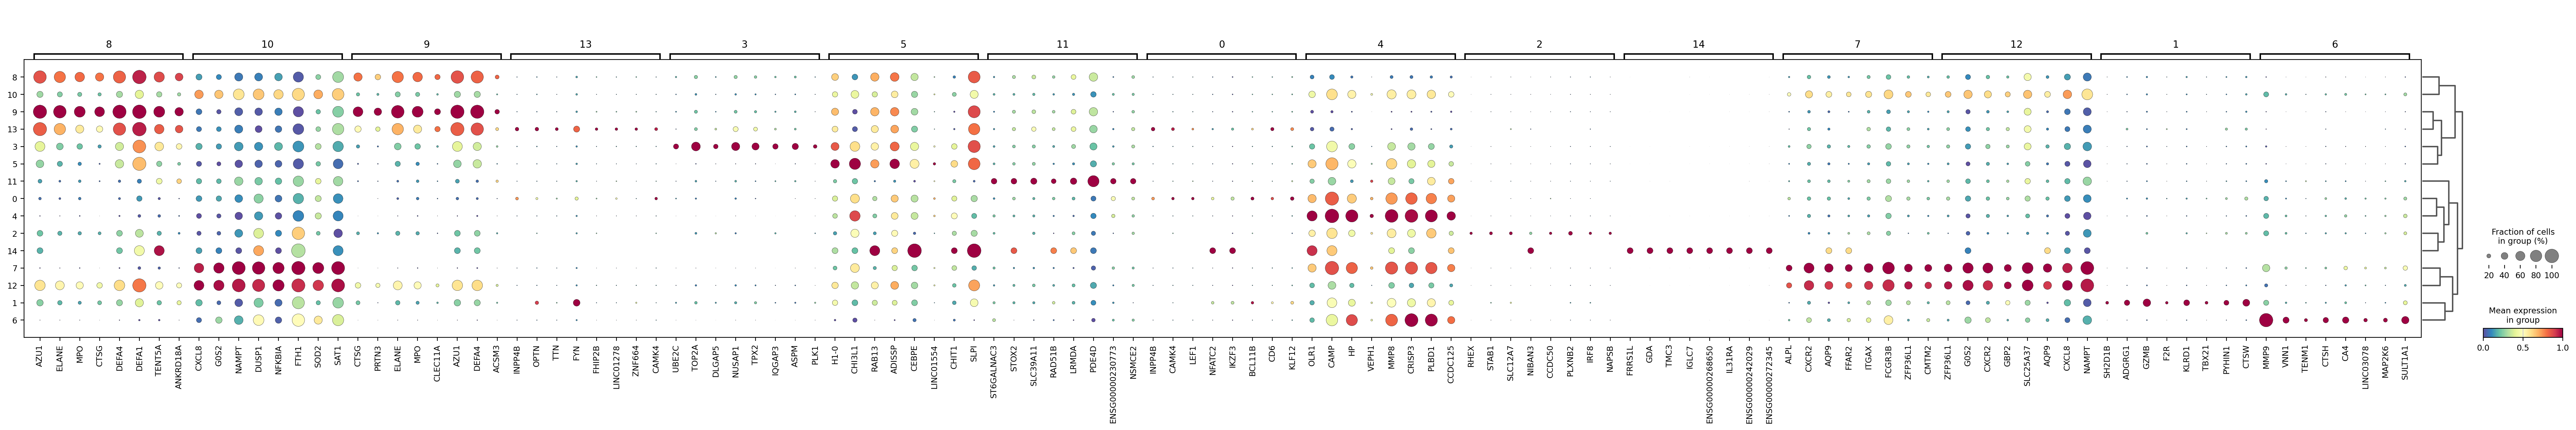

In [206]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='MKI67',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='MPO',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CD177',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'MKI67',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'CEACAM8',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'MME',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adata,'ITGAM',groupby=groupby,show=False, ax=axs[1,3],size=0)
plt.show()

In [224]:
adata.obs[groupby].value_counts()

L2_leiden_TOTALVI_1
4     24085
9     13879
5     12256
3     12238
6     12026
12    10304
7      9951
0      6807
2      3858
10     3657
13     3431
1      3065
8      3045
11     1643
14     1167
Name: count, dtype: int64

In [225]:
#都属于Immature Neutrophil，CD10- CD24+

cell_dict = {'Doublet':['0','13',#T
                        '1','14',#B
                        '10',#ADT
                       '2'],
             'CEACAM8+ Neutrophil':['3',
                                    '4','5','6','7','8','9','11','12',
                                   ],
            }

#MPO,NE=ELANE,PAD4=PADI4,Gasdermin D=GSDMD,与中性粒NETs形成相关。

#maturation: ITGAM (CD11b), FCGR3A (CD16), and MME (CD10). https://www.nature.com/articles/s41590-023-01490-5

# https://www.biocompare.com/Editorial-Articles/577944-A-Guide-to-Neutrophil-Markers/
#  CD62Llow, CXCR2low, CXCR4hi, CD11bhi;
# upregulation of CXCR4 marks neutrophils for senescence;leading them back to the bone marrow for turnover.

#Degranulation, determined as an increase of the median fluorescent intensities (MFIs)
# of CD11b and CD66b;https://www.nature.com/articles/s41598-022-07455-2

#For mature, circulating neutrophils,
# a phenotype of CD16hi, CXCR2hi, CXCR4low, and CD62Lhi has been reported.

#Neutrophil profiling illuminates anti-tumor antigen-presenting potency

#黄来源：CD101区分成熟与否,但不适合

In [226]:
check_dict_duplicates(cell_dict)

'无重复'

In [227]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2_Refine'] = i

In [228]:
(adata.obs['Celltype_L1_L2_Refine'].isna()).value_counts()

Celltype_L1_L2_Refine
False    121412
Name: count, dtype: int64

In [229]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
CEACAM8+ Neutrophil    99427
Doublet                21985
Name: count, dtype: int64

In [230]:
adata.obs.loc[adata.obs['receptor_type']=='TCR','Celltype_L1_L2_Refine']="Doublet"
adata.obs.loc[adata.obs['receptor_type_BCR']=='BCR','Celltype_L1_L2_Refine']="Doublet"

In [231]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
CEACAM8+ Neutrophil    92942
Doublet                28470
Name: count, dtype: int64

In [232]:
adata = adata[adata.obs['Celltype_L1_L2_Refine'] != "Doublet",:]

In [233]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
CEACAM8+ Neutrophil    92942
Name: count, dtype: int64

In [234]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R1_refine_indices_{celltype}.csv")

# 14. CEACAM8_Neg_Neutrophil Refine

In [235]:
celltype="CEACAM8_Neg_Neutrophil"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [236]:
adata,adt,leiden_data = get_annotation_data(celltype)

... storing 'Celltype_L1_L2' as categorical


In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [ ]:
leiden_data.to_csv(f'{R_data_path}/Level2_TOTALVI_ForClustree.csv')
os.system(f'/home/liyanguo/anaconda3/envs/R/bin/Rscript clustree_L2.R {R_data_path} &')

In [237]:
groupby = "L2_leiden_TOTALVI_2"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
cell_index = celltypist.samples.downsample_adata(adata,mode = 'each', n_cells = 5000,
                                                 by = groupby,
                                                 return_index = True,random_state=0)

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata[cell_index], keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata[cell_index], keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata[cell_index], keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata[cell_index], keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata[cell_index], keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata[cell_index], keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata[cell_index], keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L2_metadata.png')

In [ ]:
sc.pl.violin(adata,'CD177',groupby=groupby,size=0)

In [ ]:
sc.pl.violin(adata,'FUT4',groupby=groupby,size=0)

In [238]:
adata.obs[groupby].value_counts()

L2_leiden_TOTALVI_2
17    2832863
0     2299605
19    2102819
10    2093910
16    1925171
15    1909191
14    1781486
9     1717480
13    1706819
7     1680461
12    1542307
11    1257325
4     1109741
2     1092450
18     892918
21     813265
20     696426
6      673057
8      554060
3      250621
5      248201
22      96551
1       18946
23       9896
28         10
26          8
27          7
24          7
31          5
25          3
29          3
30          3
Name: count, dtype: int64

In [239]:
cell_dict = {'Doublet':['5','23',#High UMI
                       '1',#Bas
                        '3','22',#ADT
                        '24','25','28','30',
                       ],#
             'CEACAM8- Neutrophil':['0','2','4','6','7','8','9','10',
                                    '11','12','13','14','15','16','17','18','19',
                                    '20','21','26','27','29','31'],
            }

#CXCR2/CXCL8促进出骨髓，CXCR4抑制出骨髓
#C5AR1 FPR1 ADM

#maturation: ITGAM (CD11b), FCGR3A (CD16), and MME (CD10). https://www.nature.com/articles/s41590-023-01490-5

# https://www.biocompare.com/Editorial-Articles/577944-A-Guide-to-Neutrophil-Markers/
#  CD62Llow, CXCR2low, CXCR4hi, CD11bhi;upregulation of CXCR4 marks neutrophils for senescence;leading them back to the bone marrow for turnover.

#Degranulation, determined as an increase of the median fluorescent intensities (MFIs) of CD11b and CD66b;https://www.nature.com/articles/s41598-022-07455-2

#For mature, circulating neutrophils, a phenotype of CD16hi, CXCR2hi, CXCR4low, and CD62Lhi has been reported.

#Neutrophil profiling illuminates anti-tumor antigen-presenting potency

#黄来源：CD101区分成熟与否,但不适合

In [240]:
check_dict_duplicates(cell_dict)

'无重复'

In [241]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2_Refine'] = i

In [242]:
(adata.obs['Celltype_L1_L2_Refine'].isna()).value_counts()

Celltype_L1_L2_Refine
False    29305615
Name: count, dtype: int64

In [243]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
CEACAM8- Neutrophil    28681377
Doublet                  624238
Name: count, dtype: int64

In [244]:
adata = adata[adata.obs['Celltype_L1_L2_Refine'] != "Doublet",:]

In [245]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
CEACAM8- Neutrophil    28681377
Name: count, dtype: int64

In [246]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R1_refine_indices_{celltype}.csv")

# 15. pDC Refine

In [247]:
celltype="pDC"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [248]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [ ]:
leiden_data.to_csv(f'{R_data_path}/Level2_TOTALVI_ForClustree.csv')
os.system(f'/home/liyanguo/anaconda3/envs/R/bin/Rscript clustree_L2.R {R_data_path} &')

In [249]:
groupby = "L2_leiden_TOTALVI_0.5"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L2_metadata.png')

In [ ]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD79A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adt, color='CD3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],layer='denoised_protein',show=False)
#TNFAIP3/CXCR4/DDIT4/FOSL2/IRS2/BTG1/ZFP36/PNRC1/CDKN1B/PLIN2/BHLHE40/PLAUR/ETS1/DUSP1
#SELL/TXNIP/IFITM2/B2M/HLA-C

sc.pl.violin(adata,'CXCR4',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'CSF3R',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'IL16',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adt,'CD14',groupby=groupby,show=False, ax=axs[1,3],size=0.5,layer='denoised_protein')#
plt.show()

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CLEC4C',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='IL3RA',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CD7',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'SIGLEC6',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'AXL',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'FLT3',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adata,'IL6ST',groupby=groupby,show=False, ax=axs[1,3],size=0)
plt.show()

In [ ]:
sc.pl.violin(adata,'XCR1',groupby=groupby,size=0)

In [250]:
adata.obs[groupby].value_counts()

L2_leiden_TOTALVI_0.5
0    65943
1    24568
3    16650
5    10664
2     3357
4     2292
Name: count, dtype: int64

In [251]:
cell_dict = {'Doublet':['5',#T
                        '3',#Neu CD16
                        '2',#CD14 CD16- CD1c- 不确定
                       ],
             
             "pDC":['0','1','4',],
            }

# moDC	KLF4, 人：CD11c, CD11b, CD1a, CD1c (BDCA‐1),其他：CD206, CD209, CD172A
#SIGLEC6 AXL: ASDC
#cDC2 ,CD1C CLEC10A、IRF2、IRF4、RelB、RBP-J	人：CD11c, HLA-DR, CD1c (BDCA1), CD11b，FCER1A, CD2, CD172A, ILT1
#cDC1,XCR1 BATF3 IRF8, 人：CD11c, HLA-DR, CD141 (BCDA3) CLEC9A、CADM1、THBD 
# cDC2s (CD88−CD1c+CD2+CD163−, expressing or not CD5), DC3s (CD88−CD1c+CD2+CD163+, expressing or not CD14), and monocytes (CD88+CD14+CD163+), 
# A key issue is to distinguish DC3s from mo-DCs, as they display largely overlapping phenotypes (CD1c, FcεRI, and CD14) and transcriptomic signatures (CLEC10A, S100A8, S100A9, and VCAN).

In [252]:
check_dict_duplicates(cell_dict)

'无重复'

In [253]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2_Refine'] = i

In [254]:
(adata.obs['Celltype_L1_L2_Refine'].isna()).value_counts()

Celltype_L1_L2_Refine
False    123474
Name: count, dtype: int64

In [255]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
pDC        92803
Doublet    30671
Name: count, dtype: int64

In [256]:
adata.obs.loc[adata.obs['receptor_type']=='TCR','Celltype_L1_L2_Refine']="Doublet"
adata.obs.loc[adata.obs['receptor_type_BCR']=='BCR','Celltype_L1_L2_Refine']="Doublet"

In [257]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
pDC        86971
Doublet    36503
Name: count, dtype: int64

In [258]:
adata = adata[adata.obs['Celltype_L1_L2_Refine'] != "Doublet",:]

In [260]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
pDC    86971
Name: count, dtype: int64

In [259]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R1_refine_indices_{celltype}.csv")

# 16. DC Refine

In [173]:
celltype="DC"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [174]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [ ]:
leiden_data.to_csv(f'{R_data_path}/Level2_TOTALVI_ForClustree.csv')
os.system(f'/home/liyanguo/anaconda3/envs/R/bin/Rscript clustree_L2.R {R_data_path} &')

In [179]:
groupby = "L2_leiden_TOTALVI_3"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L2_metadata.png')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD163',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CLEC9A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CLEC10A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'CXCR4',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'CSF3R',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'SIGLEC6',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adt,'CD14',groupby=groupby,show=False, ax=axs[1,3],size=0.5,layer='denoised_protein')#
plt.show()

In [ ]:
sc.pl.violin(adata,'CLEC9A',groupby=groupby)

In [265]:
adata.obs[groupby].value_counts()

L2_leiden_TOTALVI_2
19    38562
0     36593
10    34988
8     33185
4     27760
3     25910
1     21502
11    20838
14    17780
2     17730
13    16261
17    15783
5     14444
12     8176
7      7368
15     6055
27     1781
6       963
24      963
21      637
9       367
25      295
20       97
18       91
23       70
28       65
16       64
26       39
22       35
29        5
Name: count, dtype: int64

In [266]:
cell_dict = {'Doublet':['7','17','24',#T
                        '27',#B
                        '12',#low UMI
                        '6','14',#ADT
                       ],
             'ASDC':['15'],

             #CD1C+ FCER1A+
             'cDC1':['21'],#CLEC9A XCR1
             'cDC2':['0','1','2','3','4','5',
                          '9','10','11','13',
                          '18','20','22','23',
                          '25','26','28','29',],
             
             'Intermediate monocyte':['8',
                                   '16',
                                   '19'],# FCER1A-
            }

# moDC	KLF4, 人：CD11c, CD11b, CD1a, CD1c (BDCA‐1),其他：CD206, CD209, CD172A
#SIGLEC6 AXL: ASDC
#cDC2 ,CD1C CLEC10A、IRF2、IRF4、RelB、RBP-J	人：CD11c, HLA-DR, CD1c (BDCA1), CD11b，FCER1A, CD2, CD172A, ILT1
#cDC1,XCR1 BATF3 IRF8, 人：CD11c, HLA-DR, CD141 (BCDA3) CLEC9A、CADM1、THBD 
# cDC2s (CD88−CD1c+CD2+CD163−, expressing or not CD5), DC3s (CD88−CD1c+CD2+CD163+, expressing or not CD14), and monocytes (CD88+CD14+CD163+), 
# A key issue is to distinguish DC3s from mo-DCs, as they display largely overlapping phenotypes (CD1c, FcεRI, and CD14) and transcriptomic signatures (CLEC10A, S100A8, S100A9, and VCAN).

In [267]:
check_dict_duplicates(cell_dict)

'无重复'

In [268]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2_Refine'] = i

In [269]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
cDC2                     217090
Intermediate monocyte     71811
Doublet                   52814
ASDC                       6055
cDC1                        637
Name: count, dtype: int64

In [270]:
(adata.obs['Celltype_L1_L2_Refine'].isna()).value_counts()

Celltype_L1_L2_Refine
False    348407
Name: count, dtype: int64

In [271]:
adata.obs.loc[adata.obs['receptor_type']=='TCR','Celltype_L1_L2_Refine']="Doublet"
adata.obs.loc[adata.obs['receptor_type_BCR']=='BCR','Celltype_L1_L2_Refine']="Doublet"

In [272]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
cDC2                     204699
Doublet                   69398
Intermediate monocyte     68192
ASDC                       5602
cDC1                        516
Name: count, dtype: int64

In [273]:
adata = adata[adata.obs['Celltype_L1_L2_Refine'] != "Doublet",:]

In [274]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
cDC2                     204699
Intermediate monocyte     68192
ASDC                       5602
cDC1                        516
Name: count, dtype: int64

In [275]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R1_refine_indices_{celltype}.csv")

# 17. Platelet Refine

In [181]:
celltype="Platelet"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [182]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [ ]:
leiden_data.to_csv(f'{R_data_path}/Level2_TOTALVI_ForClustree.csv')
os.system(f'/home/liyanguo/anaconda3/envs/R/bin/Rscript clustree_L2.R {R_data_path} &')

In [183]:
groupby = "L2_leiden_TOTALVI_0.5"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L2_metadata.png')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD79A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adt, color='CD3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],layer='denoised_protein',show=False)
#TNFAIP3/CXCR4/DDIT4/FOSL2/IRS2/BTG1/ZFP36/PNRC1/CDKN1B/PLIN2/BHLHE40/PLAUR/ETS1/DUSP1
#SELL/TXNIP/IFITM2/B2M/HLA-C

sc.pl.violin(adata,'CXCR4',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'CSF3R',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'IL16',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adt,'CD14',groupby=groupby,show=False, ax=axs[1,3],size=0.5,layer='denoised_protein')#
plt.show()

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='FCGR3B',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CD2',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'FCER1G',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'CSF3R',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'HLA-DRA',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adata,'PTPRC',groupby=groupby,show=False, ax=axs[1,3],size=0)
plt.show()

In [279]:
adata.obs[groupby].value_counts()

L2_leiden_TOTALVI_0.5
0    19091
2    10174
3     9308
1     8384
4      359
Name: count, dtype: int64

In [280]:
cell_dict = {'Doublet':['0','1','2','4'
                       ],
             'Platelet':['3',],
            }

In [281]:
check_dict_duplicates(cell_dict)

'无重复'

In [282]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2_Refine'] = i

In [283]:
(adata.obs['Celltype_L1_L2_Refine'].isna()).value_counts()

Celltype_L1_L2_Refine
False    47316
Name: count, dtype: int64

In [284]:
adata.obs.loc[adata.obs['receptor_type']=='TCR','Celltype_L1_L2_Refine']="Doublet"
adata.obs.loc[adata.obs['receptor_type_BCR']=='BCR','Celltype_L1_L2_Refine']="Doublet"

In [285]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Doublet     38008
Platelet     9308
Name: count, dtype: int64

In [286]:
adata = adata[adata.obs['Celltype_L1_L2_Refine'] != "Doublet",:]

In [288]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Platelet    9308
Name: count, dtype: int64

In [287]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R1_refine_indices_{celltype}.csv")

# 合并所有数据

In [86]:
obj_path = '/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Level2_Refine_R1/'

In [87]:
celltypes=['CEACAM8_Pos_Neutrophil','CEACAM8_Neg_Neutrophil',
           'Classical_Monocyte','Non_classical_Monocyte',
           'CD4T','CD8T',
           'CD56dimNK','CD56brightNK',
           'gdT','B','MAIT',
           'DC','pDC',
           'HSPC','iNKT',
           'Basophil','Platelet']

In [88]:
try:
    del indices_dict,combined_indices
except:
    print("It is None!")

It is None!


In [89]:
indices_dict= []
for i in tqdm(celltypes):
    indices = pd.read_csv(f'{obj_path}/{i}/R1_refine_indices_{i}.csv',index_col=0)
    indices_dict.append(indices)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [00:53<00:00,  3.13s/it]


In [90]:
combined_indices = pd.concat(indices_dict)

In [91]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

In [92]:
combined_indices

,Celltype_L1_L2,Celltype_L1_L2_Refine,receptor_type,receptor_type_BCR
D0589_Rep1_ACACGACC_TGGAACAA_CGGATTGC,CEACAM8+ Neutrophil,CEACAM8+ Neutrophil,NaN,NaN
D0589_Rep1_ACATTGGC_GACTAGTA_CAGATCTG,CEACAM8+ Neutrophil,CEACAM8+ Neutrophil,NaN,NaN
D0589_Rep1_TGAAGAGA_AGTCACTA_CGCATACA,CEACAM8+ Neutrophil,CEACAM8+ Neutrophil,NaN,NaN
D0589_Rep1_TATCAGCA_ACAGATTC_AGATGTAC,CEACAM8+ Neutrophil,CEACAM8+ Neutrophil,NaN,NaN
D0864_M_Rep2_CCTCTATC_GAACAGGC_GAGCTGAA,CEACAM8+ Neutrophil,CEACAM8+ Neutrophil,NaN,NaN
...,...,...,...,...
D0189_Rep2_AGCAGGAA_AGTCACTA_AGCACCTC,Platelet,Platelet,NaN,NaN
D0955_M_Rep2_TTCACGCA_CATACCAA_CAGCGTTA,Platelet,Platelet,NaN,NaN
D0955_M_Rep2_ACAGCAGA_CATCAAGT_CCAGTTCA,Platelet,Platelet,NaN,NaN
D0955_M_Rep2_TCCGTCTA_GCTAACGA_CACTTCGA,Platelet,Platelet,NaN,NaN


In [93]:
combined_indices['Celltype_L1_L2_Refine'].isna().value_counts()

Celltype_L1_L2_Refine
False    54971842
Name: count, dtype: int64

In [95]:
combined_indices['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
CEACAM8- Neutrophil       28681377
CD56dim NK                 4646883
Helper memory CD4+ T       4547781
Tem CD8+ T                 4329760
Classical monocyte         3256129
Naïve CD4+ T               2798231
Cytotoxic CD4+ T           1345731
Naïve B                    1232786
γδ T                        762968
Memory B                    582243
Non-classical monocyte      476812
Low quality                 376787
Naïve CD8+ T                315536
Treg                        288057
cDC2                        204699
Intermediate monocyte       195714
CD56bright NK               190641
MAIT                        150701
Atypical memory B           112350
CEACAM8+ Neutrophil          92942
pDC                          86971
CD56dim KLRG1+ NK            51473
Basophil                     51145
Plasma                       48633
Tcm CD8+ T                   47425
CD56dim CD38+ NK             36063
HSPC                         18927
Non-NK ILC                   1756

## save

In [96]:
def save_to_indices(celltype,celltype_to_file):
    L2_refine_path_R2 = '/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Level2_Refine_R2'
    indices=combined_indices['Celltype_L1_L2_Refine'].isin(celltype)
    indices_celltype=combined_indices[indices]
    print(f"{indices_celltype['Celltype_L1_L2_Refine'].value_counts()}")
    os.makedirs(f'{L2_refine_path_R2}/{celltype_to_file}', exist_ok=True)
    indices_celltype.to_csv(f"{L2_refine_path_R2}/{celltype_to_file}/R2_indices_{celltype_to_file}.csv")

In [97]:
save_to_indices(celltype=['Naïve B'],celltype_to_file='NaiveB')
save_to_indices(celltype=['Memory B','Atypical memory B'],celltype_to_file='MemoryB')
save_to_indices(celltype=['Plasma'],celltype_to_file='Plasma')

Celltype_L1_L2_Refine
Naïve B    1232786
Name: count, dtype: int64
Celltype_L1_L2_Refine
Memory B             582243
Atypical memory B    112350
Name: count, dtype: int64
Celltype_L1_L2_Refine
Plasma    48633
Name: count, dtype: int64


In [98]:
# 30 cell types, 25 folders
save_to_indices(celltype=['iNKT'],celltype_to_file='iNKT')
save_to_indices(celltype=['Mast'],celltype_to_file='Mast')
save_to_indices(celltype=['HSPC'],celltype_to_file='HSPC')
save_to_indices(celltype=['Non-NK ILC'],celltype_to_file='Non_NK_ILC')
save_to_indices(celltype=['Platelet'],celltype_to_file='Platelet')
save_to_indices(celltype=['pDC','ASDC','cDC1','cDC2',],celltype_to_file='DC')
save_to_indices(celltype=['Basophil'],celltype_to_file='Basophil')

Celltype_L1_L2_Refine
iNKT    805
Name: count, dtype: int64
Celltype_L1_L2_Refine
Mast    1800
Name: count, dtype: int64
Celltype_L1_L2_Refine
HSPC    18927
Name: count, dtype: int64
Celltype_L1_L2_Refine
Non-NK ILC    17562
Name: count, dtype: int64
Celltype_L1_L2_Refine
Platelet    9308
Name: count, dtype: int64
Celltype_L1_L2_Refine
cDC2    204699
pDC      86971
cDC1      8000
ASDC      5602
Name: count, dtype: int64
Celltype_L1_L2_Refine
Basophil    51145
Name: count, dtype: int64


In [99]:
save_to_indices(celltype=['CD56bright NK','CD56dim CD38+ NK','CD56dim KLRG1+ NK','CD56dim NK'],celltype_to_file='NK')

Celltype_L1_L2_Refine
CD56dim NK           4646883
CD56bright NK         190641
CD56dim KLRG1+ NK      51473
CD56dim CD38+ NK       36063
Name: count, dtype: int64


In [100]:
save_to_indices(celltype=['γδ T'],celltype_to_file='gdT')
save_to_indices(celltype=['MAIT'],celltype_to_file='MAIT')

Celltype_L1_L2_Refine
γδ T    762968
Name: count, dtype: int64
Celltype_L1_L2_Refine
MAIT    150701
Name: count, dtype: int64


In [101]:
save_to_indices(celltype=['Naïve CD8+ T'],celltype_to_file='NaiveCD8')
save_to_indices(celltype=['Tem CD8+ T'],celltype_to_file='TemCD8')
save_to_indices(celltype=['Tcm CD8+ T'],celltype_to_file='CD8Tcm')

Celltype_L1_L2_Refine
Naïve CD8+ T    315536
Name: count, dtype: int64
Celltype_L1_L2_Refine
Tem CD8+ T    4329760
Name: count, dtype: int64
Celltype_L1_L2_Refine
Tcm CD8+ T    47425
Name: count, dtype: int64


In [102]:
save_to_indices(celltype=['Treg'],celltype_to_file='Treg')
save_to_indices(celltype=['Naïve CD4+ T'],celltype_to_file='NaiveCD4')
save_to_indices(celltype=['Helper memory CD4+ T'],celltype_to_file='CD4_helper_memory')
save_to_indices(celltype=['Cytotoxic CD4+ T'],celltype_to_file='CytotoxicCD4')

Celltype_L1_L2_Refine
Treg    288057
Name: count, dtype: int64
Celltype_L1_L2_Refine
Naïve CD4+ T    2798231
Name: count, dtype: int64
Celltype_L1_L2_Refine
Helper memory CD4+ T    4547781
Name: count, dtype: int64
Celltype_L1_L2_Refine
Cytotoxic CD4+ T    1345731
Name: count, dtype: int64


In [103]:
save_to_indices(celltype=['Classical monocyte','Intermediate monocyte','Non-classical monocyte'],celltype_to_file='Monocyte')

Celltype_L1_L2_Refine
Classical monocyte        3256129
Non-classical monocyte     476812
Intermediate monocyte      195714
Name: count, dtype: int64


In [104]:
save_to_indices(celltype=['CEACAM8+ Neutrophil'],celltype_to_file='CEACAM8_Pos_Neutrophil')
save_to_indices(celltype=['CEACAM8- Neutrophil'],celltype_to_file='CEACAM8_Neg_Neutrophil')

Celltype_L1_L2_Refine
CEACAM8+ Neutrophil    92942
Name: count, dtype: int64
Celltype_L1_L2_Refine
CEACAM8- Neutrophil    28681377
Name: count, dtype: int64
